In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping

In [2]:
titanic_df = pd.read_csv('./data/train.csv')

titanic_df['Title'] = titanic_df['Name'].str.extract(r',\s*([^\.]+)\.')
titanic_df['Title'] = titanic_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
titanic_df['Title'] = titanic_df['Title'].replace('Mme', 'Mrs')
titanic_df['Title'] = titanic_df['Title'].replace(
    ['Dr', 'Rev', 'Major', 'Col', 'Capt', 'Lady', 'Don', 'Jonkheer', 'Sir', 'the Countess'], 'Rare'
)
titanic_df['Cabin_known'] = titanic_df['Cabin'].notnull().astype(int)
titanic_df['Deck'] = titanic_df['Cabin'].fillna('N').str[:1]

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Cabin_known,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,0,N
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0,N
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0,N


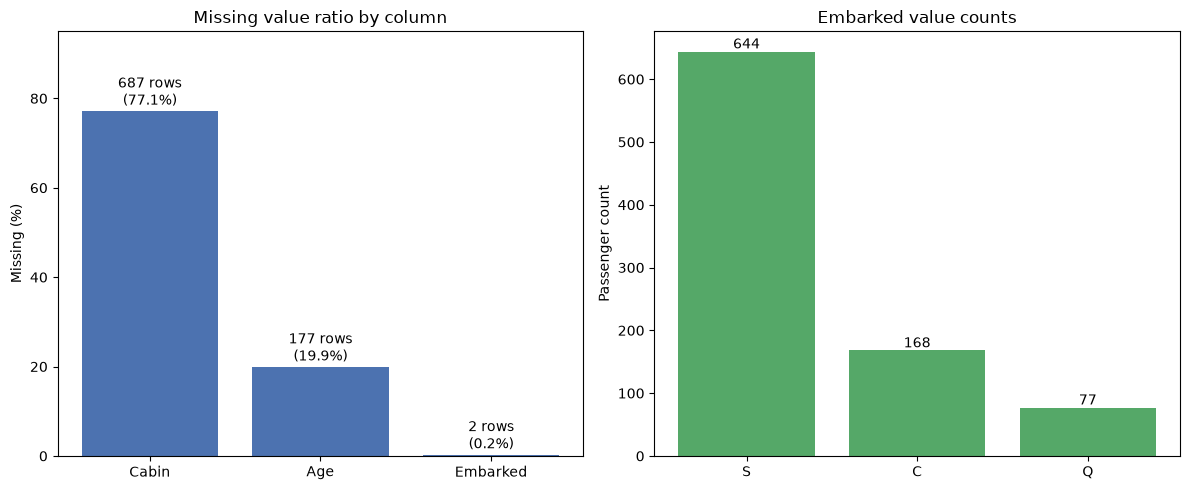

In [3]:
missing = titanic_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = missing / len(titanic_df) * 100

fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))

axes1[0].bar(missing.index, missing_pct.values, color='#4C72B0')
for i, (cnt, pct) in enumerate(zip(missing.values, missing_pct.values)):
    axes1[0].text(i, pct + 1.5, f'{cnt} rows\n({pct:.1f}%)', ha='center')
axes1[0].set_title('Missing value ratio by column')
axes1[0].set_ylabel('Missing (%)')
axes1[0].set_ylim(0, 95)

embarked_counts = titanic_df['Embarked'].value_counts()
axes1[1].bar(embarked_counts.index, embarked_counts.values, color='#55A868')
for i, v in enumerate(embarked_counts.values):
    axes1[1].text(i, v + 5, str(v), ha='center')
axes1[1].set_title('Embarked value counts')
axes1[1].set_ylabel('Passenger count')

plt.tight_layout()
plt.show()

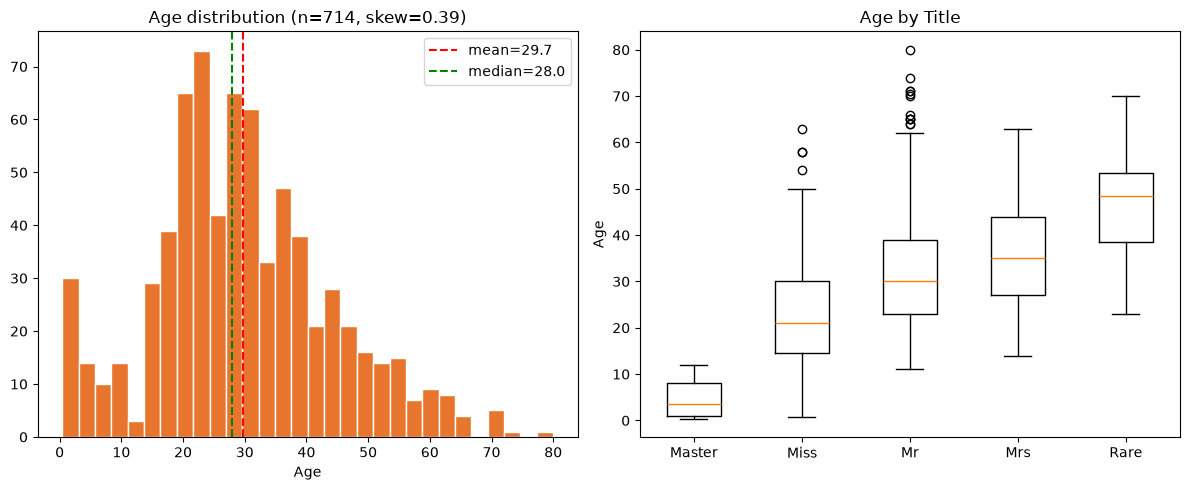

In [17]:
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

axes2[0].hist(titanic_df['Age'].dropna(), bins=30, color="#E8752E", edgecolor='white')
axes2[0].axvline(titanic_df['Age'].mean(), color='red', linestyle='--', label=f"mean={titanic_df['Age'].mean():.1f}")
axes2[0].axvline(titanic_df['Age'].median(), color='green', linestyle='--', label=f"median={titanic_df['Age'].median():.1f}")
axes2[0].set_title(f"Age distribution (n={titanic_df['Age'].notnull().sum()}, skew={titanic_df['Age'].skew():.2f})")
axes2[0].set_xlabel('Age')
axes2[0].legend()

title_order = titanic_df.groupby('Title')['Age'].median().sort_values().index
age_by_title = [titanic_df.loc[titanic_df['Title'] == t, 'Age'].dropna() for t in title_order]
axes2[1].boxplot(age_by_title, tick_labels=title_order)
axes2[1].set_title('Age by Title')
axes2[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

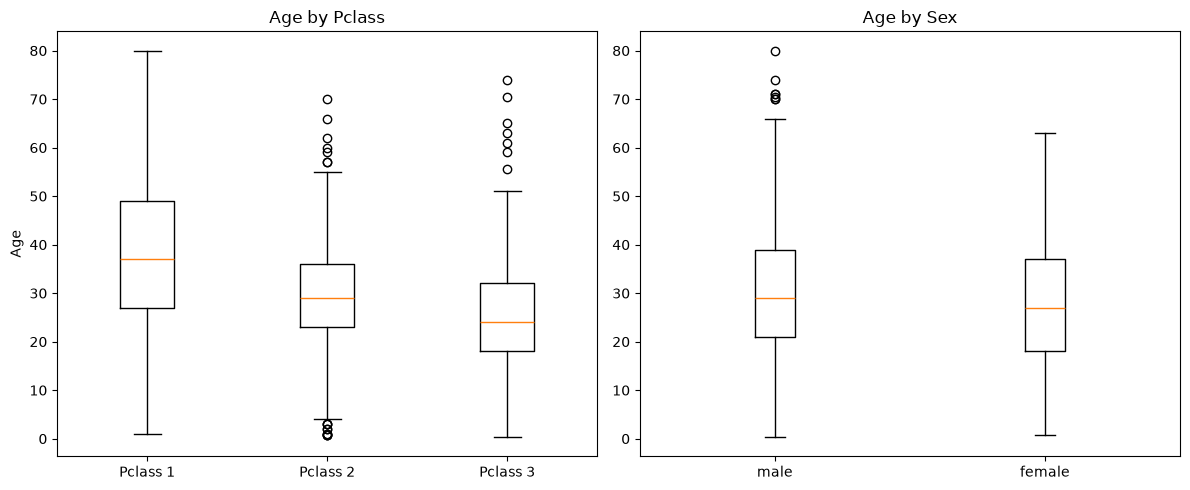

In [5]:
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))

pclass_order = sorted(titanic_df['Pclass'].unique())
age_by_pclass = [titanic_df.loc[titanic_df['Pclass'] == p, 'Age'].dropna() for p in pclass_order]
axes3[0].boxplot(age_by_pclass, tick_labels=[f'Pclass {p}' for p in pclass_order])
axes3[0].set_title('Age by Pclass')
axes3[0].set_ylabel('Age')

sex_order = ['male', 'female']
age_by_sex = [titanic_df.loc[titanic_df['Sex'] == s, 'Age'].dropna() for s in sex_order]
axes3[1].boxplot(age_by_sex, tick_labels=sex_order)
axes3[1].set_title('Age by Sex')

plt.tight_layout()
plt.show()

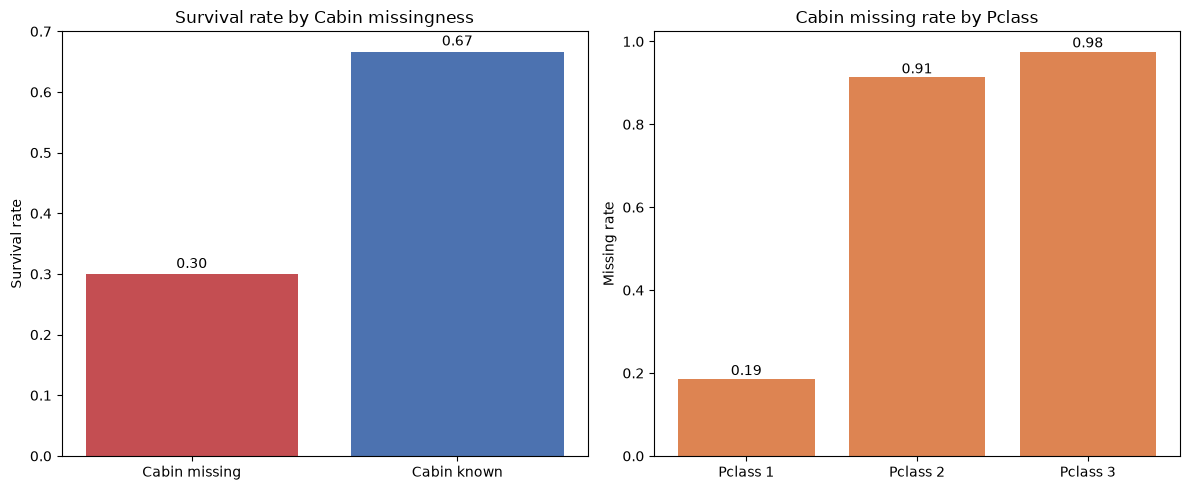

In [6]:
fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))

survival_by_cabin = titanic_df.groupby('Cabin_known')['Survived'].mean()
axes4[0].bar(['Cabin missing', 'Cabin known'], survival_by_cabin.values, color=['#C44E52', '#4C72B0'])
for i, v in enumerate(survival_by_cabin.values):
    axes4[0].text(i, v + 0.01, f'{v:.2f}', ha='center')
axes4[0].set_title('Survival rate by Cabin missingness')
axes4[0].set_ylabel('Survival rate')

missing_rate_by_pclass = 1 - titanic_df.groupby('Pclass')['Cabin_known'].mean()
axes4[1].bar([f'Pclass {p}' for p in missing_rate_by_pclass.index], missing_rate_by_pclass.values, color='#DD8452')
for i, v in enumerate(missing_rate_by_pclass.values):
    axes4[1].text(i, v + 0.01, f'{v:.2f}', ha='center')
axes4[1].set_title('Cabin missing rate by Pclass')
axes4[1].set_ylabel('Missing rate')

plt.tight_layout()
plt.show()

In [7]:
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

drop_col = ['PassengerId', 'Name', 'Ticket', 'Cabin']
X_titanic_df = X_titanic_df.drop(columns=drop_col)

X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df, y_titanic_df, test_size=0.2, random_state=42, stratify=y_titanic_df
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_tr.shape, X_val.shape, X_test.shape

((569, 10), (143, 10), (179, 10))

In [8]:
def fill_age(df, age_map, fallback):
    mask = df['Age'].isnull()
    df.loc[mask, 'Age'] = df.loc[mask, 'Title'].map(age_map).fillna(fallback)
    return df

age_map = X_tr.groupby('Title')['Age'].median()
fallback_age = X_tr['Age'].median()

X_tr = fill_age(X_tr, age_map, fallback_age)
X_val = fill_age(X_val, age_map, fallback_age)
X_test = fill_age(X_test, age_map, fallback_age)

age_map

Title
Master     3.5
Miss      22.0
Mr        30.0
Mrs       36.0
Rare      49.0
Name: Age, dtype: float64

In [9]:
embarked_mode = X_tr['Embarked'].mode()[0]
fare_median = X_tr['Fare'].median()

for df in [X_tr, X_val, X_test]:
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)
    df['Fare'] = df['Fare'].fillna(fare_median)

X_tr.isnull().sum()

Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Title          0
Cabin_known    0
Deck           0
dtype: int64

In [10]:
cat_cols = ['Sex', 'Embarked', 'Deck', 'Title']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_tr[cat_cols] = oe.fit_transform(X_tr[cat_cols])
X_val[cat_cols] = oe.transform(X_val[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

X_tr.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Cabin_known,Deck
242,2,1.0,29.0,0,0,10.5000,2.0,2.0,0,7.0
450,2,1.0,36.0,1,2,27.7500,2.0,2.0,0,7.0
721,3,1.0,17.0,1,0,7.0542,2.0,2.0,0,7.0
733,2,1.0,23.0,0,0,13.0000,2.0,2.0,0,7.0
191,2,1.0,19.0,0,0,13.0000,2.0,2.0,0,7.0


In [11]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('Confusion Matrix:\n', confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')
    return roc_auc

In [12]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_tr, y_tr)
rf_pred = rf_clf.predict(X_test)
rf_pred_proba = rf_clf.predict_proba(X_test)[:, 1]

In [13]:
xgb_clf = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric='logloss',
    random_state=42
)
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_pred = xgb_clf.predict(X_test)
xgb_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]

In [ ]:
lgbm_clf = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    eval_metric='logloss',
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
    eval_set=[(X_val, y_val)]
)

lgbm_clf.fit(
    X_tr, y_tr,
)
lgbm_pred = lgbm_clf.predict(X_test)
lgbm_pred_proba = lgbm_clf.predict_proba(X_test)[:, 1]

In [15]:
print('--- RandomForest ---')
rf_auc = get_clf_eval(y_test, rf_pred, rf_pred_proba)
print('--- XGBoost ---')
xgb_auc = get_clf_eval(y_test, xgb_pred, xgb_pred_proba)
print('--- LightGBM ---')
lgbm_auc = get_clf_eval(y_test, lgbm_pred, lgbm_pred_proba)

result = pd.DataFrame({
    'model': ['RandomForest', 'XGBoost', 'LightGBM'],
    'roc_auc': [rf_auc, xgb_auc, lgbm_auc]
}).sort_values('roc_auc', ascending=False)

result

--- RandomForest ---
Confusion Matrix:
 [[92 18]
 [20 49]]
정확도: 0.7877, 정밀도: 0.7313, 재현율: 0.7101, F1: 0.7206, AUC: 0.8303
--- XGBoost ---
Confusion Matrix:
 [[93 17]
 [24 45]]
정확도: 0.7709, 정밀도: 0.7258, 재현율: 0.6522, F1: 0.6870, AUC: 0.8157
--- LightGBM ---
Confusion Matrix:
 [[96 14]
 [26 43]]
정확도: 0.7765, 정밀도: 0.7544, 재현율: 0.6232, F1: 0.6825, AUC: 0.8211


,model,roc_auc
0,RandomForest,0.830303
2,LightGBM,0.821080
1,XGBoost,0.815679
